In [2]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

In [3]:
import os
print(os.getcwd())

c:\Users\Jordan\Documents\GitHub\Capstone-MS07\hand-gesture-recognition-mediapipe


# Specify each path

In [4]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [5]:
NUM_CLASSES = 20

# Dataset reading

In [6]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [7]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [9]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [10]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 42)                0         
                                                                 
 dense (Dense)               (None, 20)                860       
                                                                 
 dropout_1 (Dropout)         (None, 20)                0         
                                                                 
 dense_1 (Dense)             (None, 10)                210       
                                                                 
 dense_2 (Dense)             (None, 20)                220       
                                                                 
Total params: 1290 (5.04 KB)
Trainable params: 1290 (5.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [11]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [12]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000


53/57 [==========================>...] - ETA: 0s - loss: 2.8902 - accuracy: 0.1083
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.keras
57/57 [==============================] - 2s 14ms/step - loss: 2.8755 - accuracy: 0.1107 - val_loss: 2.6291 - val_accuracy: 0.1556
Epoch 2/1000
52/57 [==========================>...] - ETA: 0s - loss: 2.4836 - accuracy: 0.1950
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.keras
57/57 [==============================] - 0s 7ms/step - loss: 2.4679 - accuracy: 0.2008 - val_loss: 2.2248 - val_accuracy: 0.3778
Epoch 3/1000
50/57 [=========================>....] - ETA: 0s - loss: 2.1599 - accuracy: 0.2902
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.keras
57/57 [==============================] - 0s 7ms/step - loss: 2.1412 - accuracy: 0.2919 - val_loss: 1.9140 - val_accuracy: 0.3844
Epoch 4/1000
52/57 [==========================>...] - ETA: 0s - loss: 1.9231 - accuracy: 0.

In [14]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

19/19 [==============================] - 0s 3ms/step - loss: 0.4890 - accuracy: 0.8930


In [15]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [16]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 138ms/step
[7.6980181e-02 4.7902431e-02 2.6499098e-02 5.0945006e-02 8.8386278e-04
 3.4086319e-04 5.1631385e-01 1.5921561e-01 2.5696304e-02 9.5222786e-02
 2.2186680e-10 9.9528233e-11 4.4537096e-11 1.2295568e-09 4.2748002e-10
 8.5493716e-11 3.4325751e-09 1.7285373e-09 5.0983029e-10 1.2732576e-10]
6


In [18]:
# Extract data
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

# Print sample (or export)
for i in range(len(epochs)):
    print(f"Epoch {epochs[i]}: "
          f"Train Acc={train_acc[i]:.4f}, Val Acc={val_acc[i]:.4f}, "
          f"Train Loss={train_loss[i]:.4f}, Val Loss={val_loss[i]:.4f}")
    
import pandas as pd

df = pd.DataFrame({
    'epoch': epochs,
    'train_accuracy': train_acc,
    'val_accuracy': val_acc,
    'train_loss': train_loss,
    'val_loss': val_loss
})

df.to_csv('training_metrics.csv', index=False)

Epoch 1: Train Acc=0.1107, Val Acc=0.1556, Train Loss=2.8755, Val Loss=2.6291
Epoch 2: Train Acc=0.2008, Val Acc=0.3778, Train Loss=2.4679, Val Loss=2.2248
Epoch 3: Train Acc=0.2919, Val Acc=0.3844, Train Loss=2.1412, Val Loss=1.9140
Epoch 4: Train Acc=0.3188, Val Acc=0.4387, Train Loss=1.9176, Val Loss=1.6807
Epoch 5: Train Acc=0.3406, Val Acc=0.4877, Train Loss=1.7677, Val Loss=1.4810
Epoch 6: Train Acc=0.3623, Val Acc=0.5016, Train Loss=1.6526, Val Loss=1.3482
Epoch 7: Train Acc=0.4041, Val Acc=0.5539, Train Loss=1.5434, Val Loss=1.2593
Epoch 8: Train Acc=0.4162, Val Acc=0.5790, Train Loss=1.5008, Val Loss=1.2109
Epoch 9: Train Acc=0.4422, Val Acc=0.5831, Train Loss=1.4498, Val Loss=1.1487
Epoch 10: Train Acc=0.4571, Val Acc=0.6074, Train Loss=1.4147, Val Loss=1.1159
Epoch 11: Train Acc=0.4632, Val Acc=0.6107, Train Loss=1.3873, Val Loss=1.0837
Epoch 12: Train Acc=0.4704, Val Acc=0.6193, Train Loss=1.3712, Val Loss=1.0690
Epoch 13: Train Acc=0.4841, Val Acc=0.6177, Train Loss=1.3470

# Confusion matrix

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


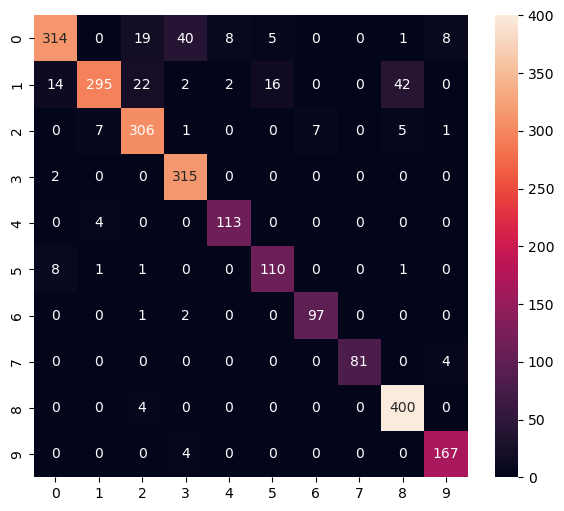

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.79      0.86       395
           1       0.96      0.75      0.84       393
           2       0.87      0.94      0.90       327
           3       0.87      0.99      0.93       317
           4       0.92      0.97      0.94       117
           5       0.84      0.91      0.87       121
           6       0.93      0.97      0.95       100
           7       1.00      0.95      0.98        85
           8       0.89      0.99      0.94       404
           9       0.93      0.98      0.95       171

    accuracy                           0.90      2430
   macro avg       0.91      0.92      0.92      2430
weighted avg       0.91      0.90      0.90      2430



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [ ]:
# Save as a model dedicated to inference
model.save(model_save_path)

In [ ]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\Harnoor\AppData\Local\Temp\tmp7eq1lowc\assets


INFO:tensorflow:Assets written to: C:\Users\Harnoor\AppData\Local\Temp\tmp7eq1lowc\assets


Saved artifact at 'C:\Users\Harnoor\AppData\Local\Temp\tmp7eq1lowc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  1904378100048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1904378101008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1904378100432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1904378101200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1904402679184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1904402678224: TensorSpec(shape=(), dtype=tf.resource, name=None)


7240

# Inference test

In [ ]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

c:\Users\Harnoor\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [ ]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 924 μs


In [ ]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[4.8658773e-02 2.9927947e-02 6.2077843e-02 6.4574614e-02 2.7865588e-05
 1.6049034e-04 4.3210718e-01 2.2050022e-01 4.3527121e-03 1.3761234e-01
 1.6362517e-11 2.7056119e-11 4.4200177e-12 3.4594003e-12 4.1906537e-11
 9.1841132e-11 1.3253626e-11 2.7935733e-12 8.3330498e-10 3.2776337e-11]
6
